In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/precious-metals-history-since-2000-with-news/final_palladium_data.csv
/kaggle/input/precious-metals-history-since-2000-with-news/final_silver_data.csv
/kaggle/input/precious-metals-history-since-2000-with-news/final_gold_data.csv
/kaggle/input/precious-metals-history-since-2000-with-news/final_platinum_data.csv


## Project Summary

This project explores the relationship between sentiment and Close-to-Open price movements for four metals — Gold, Silver, Palladium, and Platinum — from April 2020 to April 2025. The analysis includes sentiment distribution visualizations, yearly difference trends, and correlation calculations to assess how sentiment relates to short-term price changes.

Additionally, the project includes a historical event crisis analysis covering the 9/11 attacks (2001), the 2008 Financial Crisis, and the 2020 COVID Crisis. This analysis examines how each metal's price responded during these major global events, highlighting patterns in safe-haven behavior versus industrial demand sensitivity. These findings provide deeper context for understanding how precious metals typically react during periods of extreme market uncertainty and can inform expectations for future crises.


# Import Data and Combine tables

In [60]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("romanfonel/precious-metals-history-since-2000-with-news")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/precious-metals-history-since-2000-with-news


In [61]:
# Read all 4 CSV files; note: they use ';' as the delimiter instead of ','
palladium = pd.read_csv('/kaggle/input/precious-metals-history-since-2000-with-news/final_palladium_data.csv', delimiter=';')
silver = pd.read_csv('/kaggle/input/precious-metals-history-since-2000-with-news/final_silver_data.csv', delimiter = ';')
gold = pd.read_csv('/kaggle/input/precious-metals-history-since-2000-with-news/final_gold_data.csv', delimiter = ';')
platinum = pd.read_csv('/kaggle/input/precious-metals-history-since-2000-with-news/final_platinum_data.csv', delimiter = ';')

In [62]:
# Add a 'metal' Column
palladium['metal'] = 'palladium'
silver['metal'] = 'silver'
gold['metal'] = 'gold'
platinum['metal'] = 'platinum'

In [63]:
# use concat to combine into one big table
metal = pd.concat([palladium,silver,gold,platinum], ignore_index=True)

#make a copy of data
metal_copy = metal.copy()

#print the head of the new dataframe
metal.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,metal
0,2000-08-30,717.00,717.0,714.0,711.05,12.0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,palladium
1,2000-08-31,710.00,710.0,710.0,716.75,12.0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,palladium
2,2000-09-01,710.00,710.0,710.0,724.70,2.0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,palladium
3,2000-09-05,710.00,710.0,710.0,720.65,0.0,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,palladium
4,2000-09-06,720.65,710.0,710.0,738.00,0.0,usd,ounce,France Telecom Profit Increases / Locale-Based...,palladium


# EDA and Cleaning

In [64]:
# Basic information
print("Shape:", metal.shape)
print("Columns:", metal.columns.tolist())
print("\nData Types:\n", metal.dtypes)

Shape: (23574, 10)
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'currency', 'unit', 'headlines', 'metal']

Data Types:
 timestamp     object
open         float64
high         float64
low          float64
close        float64
volume       float64
currency      object
unit          object
headlines     object
metal         object
dtype: object


In [65]:
#check for missing values
print("Missing values:", metal.isnull().sum())

Missing values: timestamp    0
open         0
high         0
low          0
close        0
volume       0
currency     0
unit         0
headlines    0
metal        0
dtype: int64


In [66]:
#check for empty strings in object_type col
for col in metal.select_dtypes(include='object').columns:
    empty_count = (metal[col].str.strip() == '').sum()
    print(f"Empty strings in '{col}': {empty_count}")

Empty strings in 'timestamp': 0
Empty strings in 'currency': 0
Empty strings in 'unit': 0
Empty strings in 'headlines': 0
Empty strings in 'metal': 0


In [67]:
# Check for zeros in numeric columns numeric_cols= df.select_dtypes(include=[np.number]).columns
for col in metal.select_dtypes(include='number').columns:
    zero_count = (metal[col] == 0).sum()
    print(f"Zeros in '{col}': {zero_count}")

Zeros in 'open': 0
Zeros in 'high': 0
Zeros in 'low': 0
Zeros in 'close': 0
Zeros in 'volume': 4796


Note: The volume column contains 4796 rows with a value of 0. These may represent non-trading days (e.g., weekends or holidays) or missing data. No action will be taken for now, but further review may be needed depending on the analysis focus.

In [68]:
# Check for duplicate rowsduplicate_count= df.duplicated().sum()
duplicate_count = metal.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)


Duplicate rows: 0


In [69]:
#change timestamp to date time format
metal['timestamp'] = pd.to_datetime(metal['timestamp'])
metal.dtypes

timestamp    datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume              float64
currency             object
unit                 object
headlines            object
metal                object
dtype: object

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a rule-based, open-source sentiment analysis tool that uses a pre-built lexicon. It is protected under the MIT license.

In [70]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [71]:
# Create the 'scores' column using VADER sentiment analysis on the headlines
metal['scores'] = metal['headlines'].apply(lambda headlines: sid.polarity_scores(headlines))
metal.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,metal,scores
0,2000-08-30,717.00,717.0,714.0,711.05,12.0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,palladium,"{'neg': 0.106, 'neu': 0.74, 'pos': 0.155, 'com..."
1,2000-08-31,710.00,710.0,710.0,716.75,12.0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,palladium,"{'neg': 0.0, 'neu': 0.925, 'pos': 0.075, 'comp..."
2,2000-09-01,710.00,710.0,710.0,724.70,2.0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,palladium,"{'neg': 0.024, 'neu': 0.87, 'pos': 0.105, 'com..."
3,2000-09-05,710.00,710.0,710.0,720.65,0.0,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,palladium,"{'neg': 0.041, 'neu': 0.762, 'pos': 0.197, 'co..."
4,2000-09-06,720.65,710.0,710.0,738.00,0.0,usd,ounce,France Telecom Profit Increases / Locale-Based...,palladium,"{'neg': 0.166, 'neu': 0.695, 'pos': 0.139, 'co..."


In [72]:
# Extract the compound score and assign a sentiment type (Positive, Neutral, Negative) based on its value
metal['compound'] = metal['scores'].apply(lambda score_dict: score_dict['compound'])
metal['sentiment_type']=''
metal.loc[metal.compound>0,'sentiment_type']='POSITIVE'
metal.loc[metal.compound==0,'sentiment_type']='NEUTRAL'
metal.loc[metal.compound<0,'sentiment_type']='NEGATIVE'
metal.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,metal,scores,compound,sentiment_type
0,2000-08-30,717.00,717.0,714.0,711.05,12.0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,palladium,"{'neg': 0.106, 'neu': 0.74, 'pos': 0.155, 'com...",0.5719,POSITIVE
1,2000-08-31,710.00,710.0,710.0,716.75,12.0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,palladium,"{'neg': 0.0, 'neu': 0.925, 'pos': 0.075, 'comp...",0.7059,POSITIVE
2,2000-09-01,710.00,710.0,710.0,724.70,2.0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,palladium,"{'neg': 0.024, 'neu': 0.87, 'pos': 0.105, 'com...",0.7650,POSITIVE
3,2000-09-05,710.00,710.0,710.0,720.65,0.0,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,palladium,"{'neg': 0.041, 'neu': 0.762, 'pos': 0.197, 'co...",0.8316,POSITIVE
4,2000-09-06,720.65,710.0,710.0,738.00,0.0,usd,ounce,France Telecom Profit Increases / Locale-Based...,palladium,"{'neg': 0.166, 'neu': 0.695, 'pos': 0.139, 'co...",-0.0258,NEGATIVE


# Sentiment over time
How does sentiment change over time for different metals

In [73]:
# Create a difference column that captures the change between the open and close values 
metal['Difference'] = metal['open']-metal['close']
metal.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines,metal,scores,compound,sentiment_type,Difference
0,2000-08-30,717.00,717.0,714.0,711.05,12.0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,palladium,"{'neg': 0.106, 'neu': 0.74, 'pos': 0.155, 'com...",0.5719,POSITIVE,5.95
1,2000-08-31,710.00,710.0,710.0,716.75,12.0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,palladium,"{'neg': 0.0, 'neu': 0.925, 'pos': 0.075, 'comp...",0.7059,POSITIVE,-6.75
2,2000-09-01,710.00,710.0,710.0,724.70,2.0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,palladium,"{'neg': 0.024, 'neu': 0.87, 'pos': 0.105, 'com...",0.7650,POSITIVE,-14.70
3,2000-09-05,710.00,710.0,710.0,720.65,0.0,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,palladium,"{'neg': 0.041, 'neu': 0.762, 'pos': 0.197, 'co...",0.8316,POSITIVE,-10.65
4,2000-09-06,720.65,710.0,710.0,738.00,0.0,usd,ounce,France Telecom Profit Increases / Locale-Based...,palladium,"{'neg': 0.166, 'neu': 0.695, 'pos': 0.139, 'co...",-0.0258,NEGATIVE,-17.35


In [74]:
#look at the end of timestamp to see how recent the data is
metal['timestamp'].max()

Timestamp('2025-04-14 00:00:00')

In [75]:
#create a filter for each metal and for the last year to see most recent trends
gold = metal[(metal['metal'] == 'gold') & (metal['timestamp'] > pd.to_datetime('2020-04-14'))]
silver = metal[(metal['metal'] == 'silver')& (metal['timestamp'] > pd.to_datetime('2020-04-14'))]
palladium = metal[(metal['metal'] == 'palladium')& (metal['timestamp'] > pd.to_datetime('2020-04-14'))]
platinum = metal[(metal['metal'] == 'platinum') & (metal['timestamp'] > pd.to_datetime('2020-04-14'))]

In [76]:
#count the values for the sentiment type

gold_sent = gold['sentiment_type'].value_counts()
silver_sent = silver['sentiment_type'].value_counts()
pal_sent = palladium['sentiment_type'].value_counts()
plat_sent = platinum['sentiment_type'].value_counts()


**Sentiment Distribution for Gold, Silver, Palladium, and Platinum (04/2020 - 04/2025)**
In the following set of pie charts, we visualize the distribution of sentiment types (Positive, Neutral, Negative) for Gold, Silver, Palladium, and Platinum from April 2020 to April 2025.

Chart Layout: The four metals are displayed in a 2x2 grid, with each pie chart representing the sentiment distribution for a specific metal:

* Top-left: Gold Sentiment

* Top-right: Silver Sentiment

* Bottom-left: Palladium Sentiment

* Bottom-right: Platinum Sentiment

Sentiment Breakdown: Each pie chart shows the percentage of Positive, Neutral, and Negative sentiment based on sentiment scores calculated from news headlines.

Coloring: The segments of the pie charts represent the proportions of each sentiment type, with labels showing the percentage for each category.

These visualizations allow for an easy comparison of the overall sentiment trends across the four metals over the given period, providing insights into how public perception of these metals has evolved over time.

Text(0.5, 1.0, 'Platinum Sentiment (04/2020 - 04/2025)')

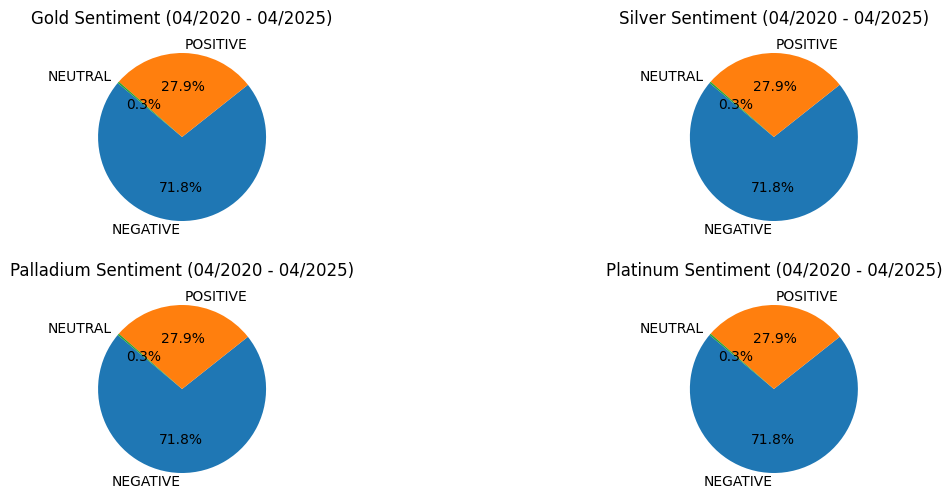

In [77]:
# Import the matplotlib.pyplot submodule and name it plt
import matplotlib.pyplot as plt

# Create a Figure and an Axes with plt.subplots
fig, ax = plt.subplots(2, 2, figsize=(14, 6))

# Plot the sentiment distribution for each metal
ax[0, 0].pie(gold_sent.values, labels=gold_sent.index, autopct='%1.1f%%', startangle=140)
ax[0, 0].set_title("Gold Sentiment (04/2020 - 04/2025)")

ax[0, 1].pie(silver_sent.values, labels=silver_sent.index, autopct='%1.1f%%', startangle=140)
ax[0, 1].set_title("Silver Sentiment (04/2020 - 04/2025)")

ax[1, 0].pie(pal_sent.values, labels=pal_sent.index, autopct='%1.1f%%', startangle=140)
ax[1, 0].set_title("Palladium Sentiment (04/2020 - 04/2025)")

ax[1, 1].pie(plat_sent.values, labels=plat_sent.index, autopct='%1.1f%%', startangle=140)
ax[1, 1].set_title("Platinum Sentiment (04/2020 - 04/2025)")


The sentiment type for each metal since 2020-04-14 is closely similar, indicating that sentiment diversity between the metals is low. This suggests that the headlines or news affecting these metals are often similar or have a unified sentiment.

In [78]:
# Extract the year from the timestamp
gold.loc[:, 'year'] = gold['timestamp'].dt.year  
silver.loc[:, 'year'] = silver['timestamp'].dt.year
palladium.loc[:, 'year'] = palladium['timestamp'].dt.year
platinum.loc[:, 'year'] = platinum['timestamp'].dt.year

# Sum the 'difference' for each year
gold_yearly = gold.groupby('year').agg({'Difference': 'sum'})  
silver_yearly = silver.groupby('year').agg({'Difference': 'sum'})
pal_yearly = palladium.groupby('year').agg({'Difference': 'sum'})
plat_yearly = platinum.groupby('year').agg({'Difference': 'sum'})

/tmp/ipykernel_31/3053794986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold.loc[:, 'year'] = gold['timestamp'].dt.year
/tmp/ipykernel_31/3053794986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  silver.loc[:, 'year'] = silver['timestamp'].dt.year
/tmp/ipykernel_31/3053794986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In the plot below, we visualize the yearly differences between the close and open prices for Gold, Silver, Palladium, and Platinum from 2020 to 2025. The data is represented as line plots, where each metal is associated with a unique color and markers to highlight the yearly changes.

X-axis: Represents the years (2020 to 2025).

Y-axis: Represents the difference between the closing and opening prices for each metal, with positive values indicating an increase from open to close, and negative values indicating a decrease.

Lines: Each metal is plotted with a different color to distinguish them:


* Gold (default color)
* Silver (red)
* Palladium(green)
* Platinum (orange)


The plot also includes markers for each data point and a legend to clearly indicate which line corresponds to which metal.

This visualization helps in identifying the trends and comparing the price differences across the metals over the years, making it easier to analyze patterns and changes in the precious metals market.

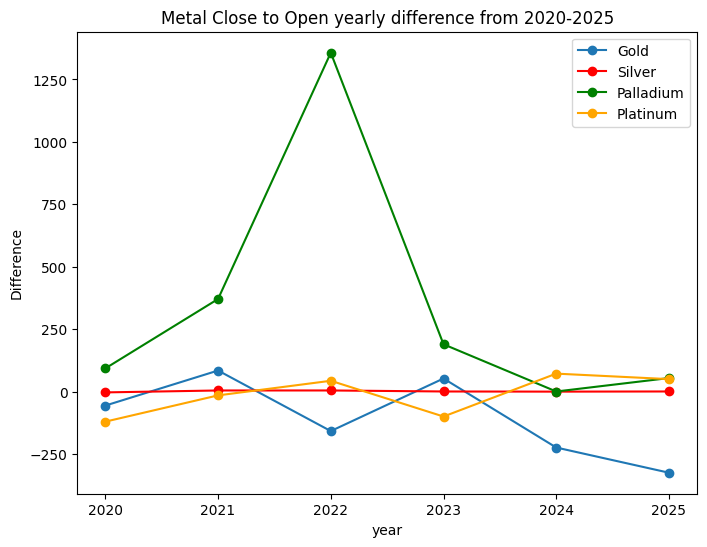

In [79]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(gold_yearly.index, gold_yearly.values, marker = 'o', label='Gold')
ax.plot(silver_yearly.index, silver_yearly.values, marker = 'o', color='r', label='Silver')
ax.plot(pal_yearly.index, pal_yearly.values, marker = 'o', color='g', label='Palladium')
ax.plot(plat_yearly.index, plat_yearly.values, marker = 'o', color='orange', label='Platinum')
ax.set_title('Metal Close to Open yearly difference from 2020-2025')
ax.set_xlabel("year")
ax.set_ylabel('Difference')
ax.legend()

**Observations:**
**Silver:** Did not show a clear trend over time, with relatively stable values throughout the years.

**Gold:** The only metal that had a lower difference in 2020 compared to 2025, showing a gradual increase in the closing vs. opening price over the period.

**Platinum:** Started with a negative difference but finished positive in 2025, indicating an upward trend in the closing price compared to the opening price over time.

**Palladium:** Exhibited a positive trend with a sharp peak in 2022, where the difference was extremely high at +1250. However, this positive difference quickly decreased in 2023 and finished on par with platinum in 2025.

# **Sentiment and Price Movement Correlation**
To explore the relationship between sentiment type and the close-to-open price difference for gold, I first converted the categorical sentiment_type column into numerical values using the following mapping:

'POSITIVE' → 1

'NEUTRAL' → 0

'NEGATIVE' → -1

This allowed me to calculate a Pearson correlation coefficient between the sentiment and the price difference:

In [80]:
import seaborn as sns

#write a funciton to set the Pearson correlation coefficient between the sentiment and the price difference for the metals

def map_sentiment_and_corr(df, sentiment_map):
    """Maps sentiment_type to numeric and returns correlation with Difference."""
    df = df.copy()  # avoid SettingWithCopyWarning
    df['sentiment_numeric'] = df['sentiment_type'].map(sentiment_map)
    return df['Difference'].corr(df['sentiment_numeric'])

sentiment_map = {'POSITIVE': 1, 'NEUTRAL': 0, 'NEGATIVE': -1}

gold_corr = map_sentiment_and_corr(gold, sentiment_map)
silver_corr = map_sentiment_and_corr(silver, sentiment_map)
palladium_corr = map_sentiment_and_corr(palladium, sentiment_map)
platinum_corr = map_sentiment_and_corr(platinum, sentiment_map)

print(f"Gold Correlation: {gold_corr}")
print(f"Silver Correlation: {silver_corr}")
print(f"Palladium Correlation: {palladium_corr}")
print(f"Platinum Correlation: {platinum_corr}")

Gold Correlation: -0.00127713043573716
Silver Correlation: -0.012754760456977744
Palladium Correlation: 0.05288998172929737
Platinum Correlation: 0.0018049651927725624


**Observations:**
Gold and Silver showed a very slight negative correlation with sentiment, indicating that sentiment had almost no predictive power for their Close-to-Open difference during the analyzed period.

Palladium and Platinum exhibited a slight positive correlation, suggesting that positive sentiment was marginally aligned with positive price differences for these metals.

Overall, the correlations are very weak across all metals, implying that sentiment alone may not be a strong driver of short-term price changes between close and open.

# Crisis Event Analysis
Identify key dates and analyez the colsing perecntage of the 4 metals

In [81]:
#create a filter function that takes in a date and filters n days before and n days after for the specifed metal
from datetime import datetime, timedelta
def event_filter(df, date, n, metal_name=None):
    before_date = date - timedelta(days = n)
    after_date = date + timedelta(days = n)
    
    mask = (df['timestamp']>= before_date) & (df['timestamp']<= after_date)

    if metal is not None:
        mask = mask  & (df['metal']==metal_name)
        
    
    return df[mask]

## Create a filted Data Frame for 9/11

In [82]:
# Use the event_filter funciton to fileter for 9/11/2001
gold_911 = event_filter(metal, pd.to_datetime('2001-9-11'), 10, metal_name='gold')
silver_911 = event_filter(metal, pd.to_datetime('2001-9-11'), 10, metal_name='silver')
palladium_911 = event_filter(metal, pd.to_datetime('2001-9-11'), 10, metal_name='palladium')
platinum_911 = event_filter(metal, pd.to_datetime('2001-9-11'), 10, metal_name='platinum')

### Metal Price Open and Close Rates (9/5/2011 - 9/21/2011)

The following plots display the open and close rates for four metals during the period of 9/5/2001 to 9/21/2001, with data points marked for each day records are avaliable. 

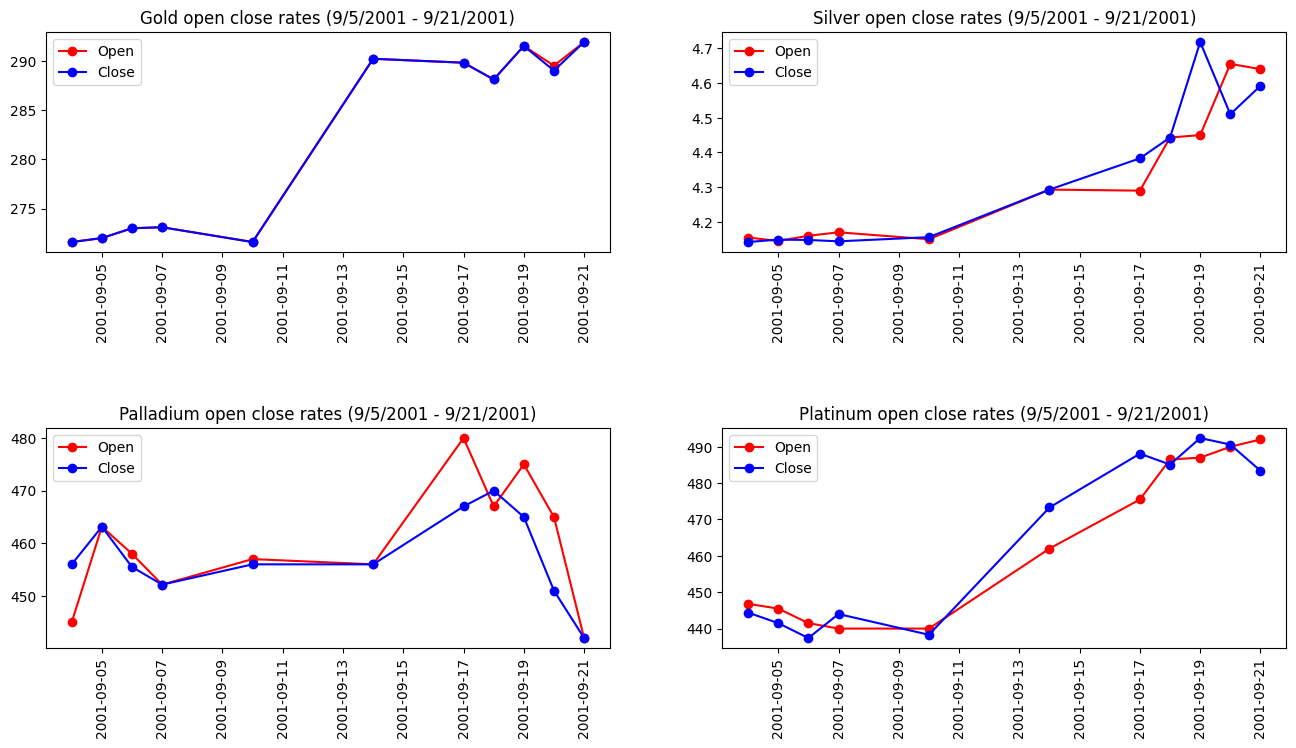

In [83]:
# create a plot for all for metals
fig, ax = plt.subplots(2, 2, figsize=(16, 8))
#Gold plot
ax[0,0].plot(gold_911['timestamp'], gold_911['open'], marker = 'o', label='Open', color='r')
ax[0,0].plot(gold_911['timestamp'], gold_911['close'], marker = 'o', label='Close', color = 'b')
ax[0, 0].set_title("Gold open close rates (9/5/2001 - 9/21/2001)")
ax[0,0].tick_params(axis='x', rotation=90)
ax[0,0].legend()

#Silver plot
ax[0,1].plot(silver_911['timestamp'], silver_911['open'], marker = 'o', color='r', label='Open')
ax[0,1].plot(silver_911['timestamp'], silver_911['close'], marker = 'o', color='b', label='Close')
ax[0,1].tick_params(axis='x', rotation=90)
ax[0, 1].set_title("Silver open close rates (9/5/2001 - 9/21/2001)")
ax[0,1].legend()

#Palladium Plot
ax[1,0].plot(palladium_911['timestamp'], palladium_911['open'], marker = 'o', color='r', label='Open')
ax[1,0].plot(palladium_911['timestamp'], palladium_911['close'], marker = 'o', color='b', label='Close')
ax[1,0].tick_params(axis='x', rotation=90)
ax[1, 0].set_title("Palladium open close rates (9/5/2001 - 9/21/2001)")
ax[1,0].legend()

#Platinum Plot
ax[1,1].plot(platinum_911['timestamp'], platinum_911['open'], marker = 'o', color='r', label='Open')
ax[1,1].plot(platinum_911['timestamp'], platinum_911['close'], marker = 'o', color='b', label='Close')
ax[1,1].tick_params(axis='x', rotation=90)
ax[1, 1].set_title("Platinum open close rates (9/5/2001 - 9/21/2001)")
ax[1,1].legend()

# Adjust the spacing between the subplots
plt.subplots_adjust(hspace=0.8)  # Increase hspace to add more space between rows

### 9/11 Crisis Observations:

**Gold**:
   - Gold prices rose sharply from around `$270` on 9/10/2001 to `$290` by 9/14/2001. Although prices fluctuated between 9/14 and 9/21, they remained elevated compared to pre-9/11 levels, indicating a flight to safety during heightened market uncertainty.
   
**Silver**:
   - Silver experienced a small upward movement after 9/11, with rates ranging between `$4.2` and `$4.7` during this time. While there was some fluctuation, it was minimal. Overall, the silver market showed a positive trend, but its low price range meant the impact was not as pronounced compared to other metals.

**Palladium**:
   - Palladium’s open and close rates remained fairly stable until 9/14, when both prices saw a significant increase. However, by 9/19, palladium prices fell substantially, from `$475` (open) and `$465` (close) to `$440` for both by 9/21/2001. This indicates a sharp decline following an initial rise, potentially driven by broader market sentiment or changing demand.

**Platinum**:
   - Platinum's rates experienced a notable increase despite the tragic events on 9/11. On 9/10, the open rate was `$440`, but by 9/17, it had risen to `$475` (open) and `$485` (close), and continued rising thereafter. This suggests a strong positive sentiment toward platinum during this period, potentially due to its use in industrial applications or as an alternative investment.


## Create a filtered data frame for the 2008 Financial Crisis

In [84]:
# Use the event_filter funciton to fileter for Lehman Brothers Bankrupscy 9/15/2008
gold_2008 = event_filter(metal, pd.to_datetime('2008-9-15'), 10, metal_name='gold')
silver_2008 = event_filter(metal, pd.to_datetime('2008-9-15'), 10, metal_name='silver')
palladium_2008 = event_filter(metal, pd.to_datetime('2008-9-15'), 10, metal_name='palladium')
#platinum_2008 = event_filter(metal, pd.to_datetime('2008-10-01'), 10, metal_name='platinum')


## There is no data for Platinum for the 2008 Crisis 


### Metal Price Open and Close Rates (9/5/2008 - 9/25/2008)

The following plots display the open and close rates for four metals during the period of 9/5/2008 - 9/25/2008, with data points marked for each day records are avaliable. 

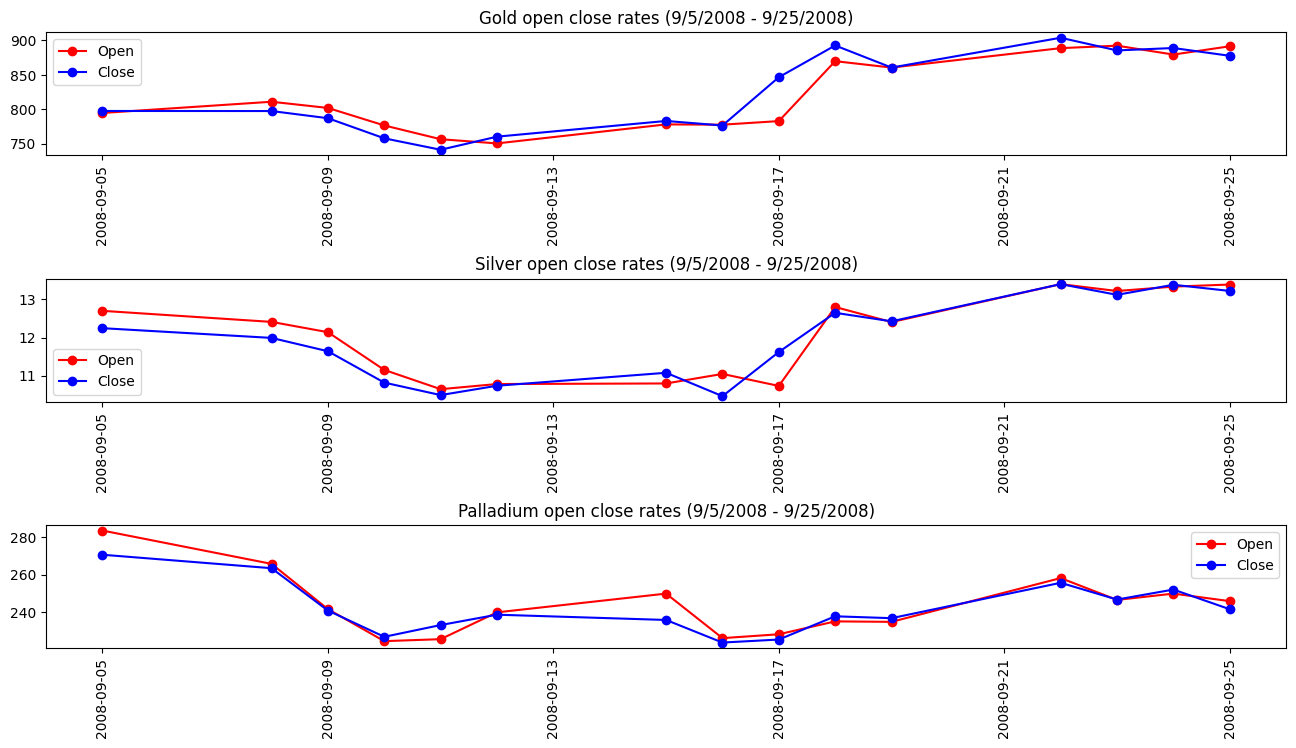

In [85]:
# create a plot for all for metals
fig, ax = plt.subplots(3,1 , figsize=(16, 8))
#Gold plot
ax[0].plot(gold_2008['timestamp'], gold_2008['open'], marker = 'o', label='Open', color='r')
ax[0].plot(gold_2008['timestamp'], gold_2008['close'], marker = 'o', label='Close', color = 'b')
ax[0].set_title("Gold open close rates (9/5/2008 - 9/25/2008)")
ax[0].tick_params(axis='x', rotation=90)
ax[0].legend()

#Silver plot
ax[1].plot(silver_2008['timestamp'], silver_2008['open'], marker = 'o', color='r', label='Open')
ax[1].plot(silver_2008['timestamp'], silver_2008['close'], marker = 'o', color='b', label='Close')
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Silver open close rates (9/5/2008 - 9/25/2008)")
ax[1].legend()

#Palladium Plot
ax[2].plot(palladium_2008['timestamp'], palladium_2008['open'], marker = 'o', color='r', label='Open')
ax[2].plot(palladium_2008['timestamp'], palladium_2008['close'], marker = 'o', color='b', label='Close')
ax[2].tick_params(axis='x', rotation=90)
ax[2].set_title("Palladium open close rates (9/5/2008 - 9/25/2008)")
ax[2].legend()

# Adjust the spacing between the subplots
plt.subplots_adjust(hspace=1.0)  # Increase hspace to add more space between rows

## 2008 Financial Crisis Observations

- **Gold**: Prices dipped slightly immediately after 9/15/2008, but quickly surged. By 9/17, gold opened at `$800` and closed at `$850`. By 9/25, it was closing around `$875`. This suggests that investors turned to gold as a safe-haven asset during the market turmoil, driving prices higher.
  
- **Silver**: Silver showed a similar pattern, falling from around `$11` to `$10` on 9/15, but by 9/18 was opening and closing near `$13`. Although silver's overall price level remained much lower than gold, it also experienced a strong post-crisis rebound, indicating renewed investor demand.

- **Palladium**: Palladium also declined immediately after 9/15. Its recovery was slower compared to gold and silver; 10 days later, palladium prices had only returned close to pre-crisis levels, unlike gold which climbed significantly higher. This slower recovery may reflect lower safe-haven demand for palladium during the crisis.


## Create a filtered Data Frame for COVID Crash

In [86]:
gold_2020 = event_filter(metal, pd.to_datetime('2020-03-10'), 22, metal_name='gold')
silver_2020 = event_filter(metal, pd.to_datetime('2020-03-10'), 22, metal_name='silver')
palladium_2020 = event_filter(metal, pd.to_datetime('2020-03-10'), 22, metal_name='palladium')
platinum_2020 = event_filter(metal, pd.to_datetime('2020-03-10'), 22, metal_name='platinum')


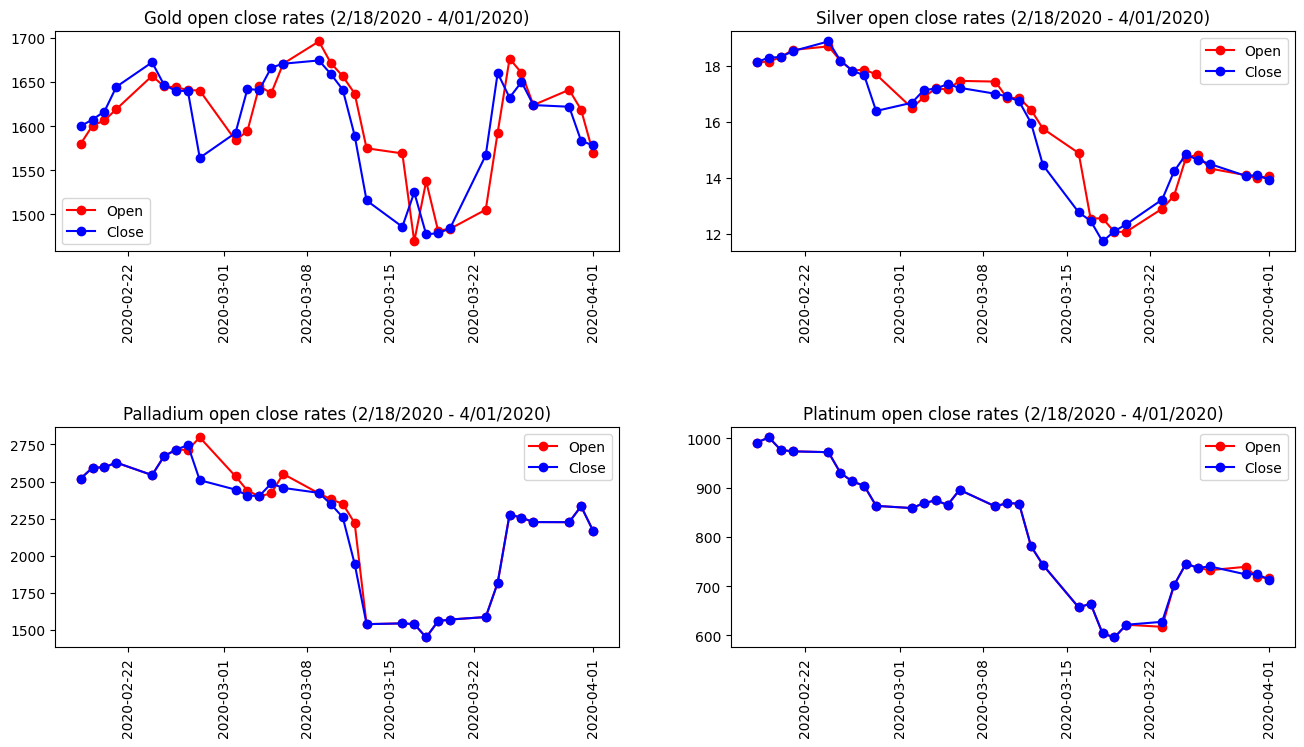

In [87]:
# create a plot for all for metals
fig, ax = plt.subplots(2, 2, figsize=(16, 8))
#Gold plot
ax[0,0].plot(gold_2020['timestamp'], gold_2020['open'], marker = 'o', label='Open', color='r')
ax[0,0].plot(gold_2020['timestamp'], gold_2020['close'], marker = 'o', label='Close', color = 'b')
ax[0, 0].set_title("Gold open close rates (2/18/2020 - 4/01/2020)")
ax[0,0].tick_params(axis='x', rotation=90)
ax[0,0].legend()

#Silver plot
ax[0,1].plot(silver_2020['timestamp'], silver_2020['open'], marker = 'o', color='r', label='Open')
ax[0,1].plot(silver_2020['timestamp'], silver_2020['close'], marker = 'o', color='b', label='Close')
ax[0,1].tick_params(axis='x', rotation=90)
ax[0, 1].set_title("Silver open close rates (2/18/2020 - 4/01/2020)")
ax[0,1].legend()

#Palladium Plot
ax[1,0].plot(palladium_2020['timestamp'], palladium_2020['open'], marker = 'o', color='r', label='Open')
ax[1,0].plot(palladium_2020['timestamp'], palladium_2020['close'], marker = 'o', color='b', label='Close')
ax[1,0].tick_params(axis='x', rotation=90)
ax[1, 0].set_title("Palladium open close rates (2/18/2020 - 4/01/2020)")
ax[1,0].legend()

#Platinum Plot
ax[1,1].plot(platinum_2020['timestamp'], platinum_2020['open'], marker = 'o', color='r', label='Open')
ax[1,1].plot(platinum_2020['timestamp'], platinum_2020['close'], marker = 'o', color='b', label='Close')
ax[1,1].tick_params(axis='x', rotation=90)
ax[1, 1].set_title("Platinum open close rates (2/18/2020 - 4/01/2020)")
ax[1,1].legend()

# Adjust the spacing between the subplots
plt.subplots_adjust(hspace=0.8)  # Increase hspace to add more space between rows

## 2020 COVID Crisis Observations

- **Gold**: From 3/08/2020, gold prices fell significantly, dropping from around `$1700` to `$1481` by 3/19. However, starting 3/20, gold saw a sharp upward trend, rising from `$1483` to `$1676` by 3/25, and settling around `$1600` by 4/1. This suggests that despite initial liquidity-driven selling, gold reasserted its role as a safe-haven asset during the crisis.

- **Silver**: Silver prices also fell sharply, dropping from `$17.4` on 3/08 to `$12.5` by 3/17, and settling around `$10` by 4/1. The steep decline suggests that silver, being more of an industrial metal compared to gold, faced stronger pressure from economic slowdown fears, though it still shared some safe-haven characteristics later.

- **Palladium**: Palladium experienced the biggest drop, falling from a peak of `$2797` on 2/28 to `$1449` by 3/18, before rebounding to around `$2169` by 4/1. This sharp collapse and partial recovery suggest that palladium, heavily tied to industrial demand (especially the auto sector), was hit hard by expectations of an economic slowdown but regained some ground as markets stabilized.

- **Platinum**: Platinum was already on a downward trend heading into March, falling from `$858` on 3/02 to a low of `$595` by 3/19, and settling at `$717` by 4/1. This continued weakness suggests that platinum, like palladium, was heavily impacted by concerns over industrial demand, particularly in automotive and manufacturing sectors.


## Crisis Conclusion

Across three major crises — the 2001 9/11 attacks, the 2008 Financial Crisis, and the 2020 COVID Crisis — a few clear patterns emerge in the precious metals market:

- **Gold consistently reasserts itself as a safe-haven asset.**  
  In every event, gold initially faced volatility but ultimately experienced strong upward momentum as investors sought security during uncertain times.
  
- **Silver, while benefiting from some safe-haven demand, is more influenced by industrial concerns.**  
  Silver showed upward trends after each crisis, but its initial declines were often steeper than gold's, reflecting its dual role as both a monetary and industrial metal.

- **Palladium and Platinum are more sensitive to industrial and economic health.**  
  Both metals showed deeper initial declines, with slower or partial recoveries, especially during events heavily tied to fears of economic contraction like the 2008 Financial Crisis and the COVID pandemic.

### Prediction for Future Crises

If another major crisis were to occur, it is likely that **gold would again see strong safe-haven inflows after an initial liquidity-driven selloff**, while **silver might mirror gold's trajectory but with more volatility**.  
**Palladium and platinum would likely face sharper short-term declines**, tied to fears of industrial slowdown, but could recover depending on the severity and duration of the economic impact.

Overall, **gold remains the most reliable performer during crisis periods**, with silver partially following, and palladium/platinum acting more as indicators of underlying economic expectations rather than pure safe-havens.
